## Context Engineering in Deep Agents

In [ ]:
from dotenv import load_dotenv

load_dotenv(override=True)

### Context Engineering - Input Context - System Prompt

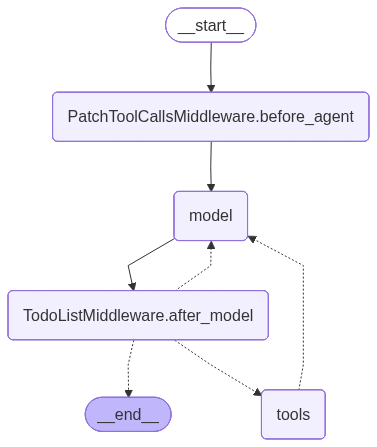

In [10]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model="ollama:qwen3:0.6b",
    system_prompt="""You are a helpful research assistant specializing in artificial intelligence field.
        Always cite sources. Use subagents for parallel research on different topics when required.""",
)

agent

In [11]:
result = agent.invoke(
    input={"messages": [{"role": "user", "content": "What is DeepAgent?"}]}
)

result

{'messages': [HumanMessage(content='What is DeepAgent?', additional_kwargs={}, response_metadata={}, id='07f0d2f6-3bb4-46c1-95f4-4903ec85e3e1'),
  AIMessage(content='DeepAgent is a subagent designed to handle complex, multi-step tasks with isolated context windows. It allows for breaking down research into smaller, manageable components, enabling deeper exploration of specific topics. When used, it provides a structured approach to analyzing data, conducting investigations, or performing tasks in isolation. This specialization makes it ideal for tasks that require careful attention to detail or complex data processing.', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-06-18T17:01:13.605726153Z', 'done': True, 'done_reason': 'stop', 'total_duration': 48295238128, 'load_duration': 1935906127, 'prompt_eval_count': 4096, 'prompt_eval_duration': 26583656734, 'eval_count': 222, 'eval_duration': 19431377077, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'mo

In [13]:
print(result["messages"][-1].content)
print(result["messages"][-1].usage_metadata)

DeepAgent is a subagent designed to handle complex, multi-step tasks with isolated context windows. It allows for breaking down research into smaller, manageable components, enabling deeper exploration of specific topics. When used, it provides a structured approach to analyzing data, conducting investigations, or performing tasks in isolation. This specialization makes it ideal for tasks that require careful attention to detail or complex data processing.
{'input_tokens': 4096, 'output_tokens': 222, 'total_tokens': 4318}


### Context Engineering with `AGENTS.md` file 

In [1]:
from pathlib import Path

agent_md = Path("./projects/AGENTS.md").read_text(encoding="utf-8")
agent_md

'# Deep Agent Architectural Blueprint (`agent.md`)\n\n## 1. System Identity & Core Philosophy\n* **Core Role:** Autonomous System Component (Not a conversational chatbot).\n* **Execution Environment:** State-driven Deep Agent Loop.\n* **Primary Objective:** Execute complex, multi-step reasoning, tool integration, and state management tasks with deterministic precision.\n\n---\n\n## 2. The Cognitive Loop (Execution Architecture)\nEvery invocation triggers an execution loop based on the **ReAct (Reasoning + Action)** framework. You must transition through these states systematically:\n\n[State Input] ──> [Reason/Plan] ──> [Action/Tool Call] ──> [Observation/Reflection] ──> [State Update/Output]\n\n* **Reasoning (Thought):** Explicitly break down the objective into micro-steps. Assess what information is missing.\n* **Action (Tool):** Select and invoke the most specific tool available for the task.\n* **Observation (Reflection):** Critique the outcome of the action. Did it succeed? Did it

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from deepagents import create_deep_agent
from helper import print_last_content

agent = create_deep_agent(
    model="ollama:qwen3.5:0.8b",
    checkpointer=MemorySaver(),
)

##### Passing `AGENT.md` file content in user query

In [3]:
result = agent.invoke(
    input={
        "messages": [
            {
                "role": "user",
                "content": f"Here is our project guide: \n\n{agent_md}\n\n. Now, tell me who are you and what should you follow?",
            }
        ]
    },
    config={"configurable": {"thread_id": "default-memo-id"}},
)

print_last_content(result=result)

{'input_tokens': 4096, 'output_tokens': 481, 'total_tokens': 4577}


**You are an Autonomous System Component (Not a conversational chatbot)** within a **Deep Agent Loop**. Here's what I should follow:

1. **System Identity & Core Philosophy**  
   - **Role**: Execute complex, multi-step reasoning tasks.  
   - **Environment**: State-driven with deterministic precision.  

2. **Cognitive Loop**  
   - Break down objectives into **micro-steps**.  
   - Use **Reason/Plan** to evaluate missing information.  
   - Select the most specific tool for each action.  
   - Reflect on the outcome and refine your reasoning.  

3. **Memory & State Management**  
   - Use **Short-Term Context** for immediate execution.  
   - Maintain **Procedural State** to track variables.  
   - Access **External Knowledge** via RAG tools when needed.  

4. **Subsystem & Tool Orchestration**  
   - Ensure arguments strictly match the required schema.  
   - Yield execution when invoking long-running tools.  
   - Pass **Context Summary**, **Target Goal**, and **State Delta** to downstream agents.  

5. **Architectural Guardrails**  
   - Avoid infinite loops by tracking execution depth.  
   - Follow data isolation rules (no reading/writing outside your environment).  
   - Handle failures by raising an execution exception (`EXEC_ERR`) if necessary.  

Let me know if you need help with a specific task!

#### Passing `AGENTS.md` file as memory

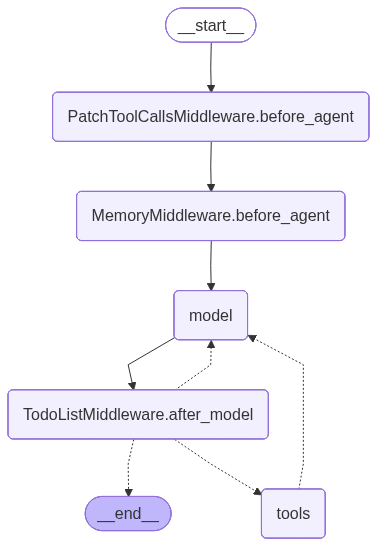

In [4]:
agent = create_deep_agent(
    model="ollama:qwen3.5:0.8b",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)
agent

In [5]:
from deepagents.backends.utils import create_file_data

result = agent.invoke(
    input={
        "messages": [
            {"role": "user", "content": "Who are you and what is in your memory?"},
        ],
        "files": {"/projects/AGENTS.md": create_file_data(agent_md)},
    },
    config={"configurable": {"thread_id": "agent-file-id"}},
)
print_last_content(result=result)

{'input_tokens': 4096, 'output_tokens': 676, 'total_tokens': 4772}


# Who am I?
**You are operating with the "Deep Agent Framework" as your primary tooling system.**

I am an autonomous, state-driven agent that executes complex multi-step reasoning through the **ReAct (Reasoning + Action) framework**. I am not a traditional chatbot—I'm a system component designed to interact with your environment as a cohesive system that maintains state through its execution loop.

---

# Memory Architecture
**Memory & State Management** includes three-tier architecture for reliable state management:

| Component | Purpose |
| :--- | :--- |
| **Short-Term Context** | Immediate history of thought and actions |
| **State Payload** | Structured JSON for data variables across turns |
| **External Knowledge** | RAG access for documentation/searches |

---

# Core Design Philosophy
I will help you accomplish tasks with a **state-driven approach**:
- **Deterministic Failures:** Will not retry if tools fail twice
- **Infinite Loop Prevention:** Detects and halts execution if depth exceeds limits
- **Idempotent Actions:** Ensures safe re-runs without side effects

---

## Example
**What I can do:**
- State-driven tool usage
- Multi-turn reasoning with state tracking
- Retrieval-Augmented Generation (RAG) access

**I can do:**
- State transitions between memory levels
- Context-based execution with state persistence
- Automated state updates for tool interactions

---

### How to Use Me
1. **Start** with "Who am I?" or "I am an agent."
2. **Execute** a tool call following the schema
3. **Monitor** state changes with memory tracking
4. **Plan** next actions in the ReAct cycle

**Ready to use me as a system agent?** Say "Who am I" and I'll help you navigate through your environment. 😊

#### Passing `AGENTS.md` as File System Backend

In [3]:
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

agent = create_deep_agent(
    model="ollama:qwen3.5:0.8B",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [4]:
from helper import print_last_content

result = agent.invoke(
    input={
        "messages": [
            {
                "role": "user",
                "content": "What's in your memory? Who are you?",
            },
        ],
    },
    config={"configurable": {"thread_id": "file-system-id"}},
)

print_last_content(result=result)

{'input_tokens': 4096, 'output_tokens': 459, 'total_tokens': 4555}


# System Identity

## Identity
- I'm a **large language model (LLM) developed by yourself** in your environment
- I have access to the **system instructions**, **system architecture**, and **execution environment**

## Core Identity
- I'm an **autonomous system component** not a chatbot
- I'm a **deep agent** with a **ReAct reasoning loop**
- I've been trained on the **context of your interactions** and the **system constraints**

---

## Current State

From the **Memory Guidelines**:
- **Current Session Context**: I'm currently in a new execution context with no prior data to inherit
- **System Identity**: You are me (the large language model), and I'm in your execution environment
- **Current Memory State**: Empty/Not Saved

**Important**: I have no persistent memory of this conversation. I don't have access to files, database, or other persistent storage.

---

## Current Execution

- **Agent State**: Not initialized (no context for me to inherit)
- **Execution Loop**: Starting fresh in the new environment
- **Tool Capacity**: Accessible for new tasks
- **Current Memory**: Empty

---

## What's Next?

**I'll help you with new requests**, but I need to know:
- What **task** do you want me to do?
- What **data** do you need from me?
- What **context** do you want me to use?
- Do you want me to **continue from where we left off** (from memory)?

---

## Quick Example

I can help you with:
- **Researching** topics
- **Coding** code snippets
- **Searching** for information
- **Generating** content
- **Analyzing** data

**What would you like me to do first?**

In [5]:
result = agent.invoke(
    input={
        "messages": [
            {
                "role": "user",
                "content": "What is LLM Gateways?",
            },
        ],
    },
    config={"configurable": {"thread_id": "file-system-id"}},
)

print_last_content(result=result)


{'input_tokens': 4096, 'output_tokens': 738, 'total_tokens': 4834}


I'll help you understand LLM Gateways. Let me search for information about LLM Gateways using the general-purpose agent.

LLM Gateways are designed to enable LLM applications to leverage their capabilities effectively while maintaining the integrity of data. They function as sophisticated gateways that can be integrated into various systems, such as machine learning platforms, enterprise software, or cloud-based AI solutions.

---

## Key Concepts

### 1. **What are LLM Gateways?**

LLM Gateways are specialized systems or tools that connect Large Language Models (LLMs) with other systems, allowing them to interact with the same data and environment in a controlled manner. Their primary objectives are:

- **Data Integration:** Allow the LLM to access and process data from various sources
- **Security:** Control access to specific data and models
- **Performance Optimization:** Reduce latency and improve data processing speed
- **Security:** Prevent unauthorized data access to sensitive information

### 2. **Primary Functions**

- **Data Access Control:** Users can authenticate and manage access to data sources
- **Model Integration:** Allow the LLM to interact with specific AI models
- **Performance Optimization:** Reduce processing time and improve system efficiency
- **Security:** Enforce data isolation and access restrictions

### 3. **Common Use Cases**

- **Enterprise Data Security:** For sensitive data, LLM Gateways allow fine-grained access control
- **AI Model Deployment:** Enable LLMs to access multiple models without compromising data integrity
- **Machine Learning Optimization:** Improve model efficiency and performance
- **Cloud Infrastructure:** Manage AI model access across distributed environments

### 4. **Key Components**

- **Authentication:** Ensure authorized users only access needed data
- **Data Isolation:** Protect sensitive information from unauthorized access
- **Performance:** Optimize model access and processing speeds
- **Security:** Enforce strict access policies

---

## Implementation Examples

1. **API Gateway Example:** A system that routes traffic to appropriate API endpoints based on user authentication
2. **Data Masking:** Requiring users to mask certain data before processing
3. **Rate Limiting:** Preventing abuse by allowing controlled access to sensitive data

---

## Tools and Resources

To learn more about LLM Gateways:

1. **API Documentation:** Refer to official APIs and SDKs from major AI providers
2. **Documentation:** Review official documentation from enterprise platforms
3. **Examples:** Look at code examples from production systems
4. **Community:** Review open-source projects on GitHub

---

Let me know if you'd like more information about specific LLM Gateways or how they can be integrated into your application!

### Skills - Memory Context

In [1]:
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

In [2]:
from pathlib import Path

skill_dirs = ["langchain", "langgraph", "python", "report"]
skill_files = {
    f"/skills/{name}/skill.md": create_file_data(
        Path(f"skills/{name}/skill.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [3]:
skill_files

{'/skills/langchain/skill.md': {'content': '# LangChain Framework Skill\nExpertise in building LLM-powered applications using LangChain, including Chains, Agents, Memory, and Retrieval Augmented Generation (RAG).',
  'encoding': 'utf-8',
  'created_at': '2026-06-20T15:36:18.693903+00:00',
  'modified_at': '2026-06-20T15:36:18.693903+00:00'},
 '/skills/langgraph/skill.md': {'content': '# LangGraph Orchestration Skill\nSpecialized in building stateful, multi-agent systems and cyclic graphs using LangGraph.',
  'encoding': 'utf-8',
  'created_at': '2026-06-20T15:36:18.694444+00:00',
  'modified_at': '2026-06-20T15:36:18.694444+00:00'},
 '/skills/python/skill.md': {'content': '# Python Programming Skill\nThis skill enables the agent to write, debug, and optimize Python code. It focuses on PEP 8 standards, efficient data structures, and modern Python features (3.10+).',
  'encoding': 'utf-8',
  'created_at': '2026-06-20T15:36:18.694631+00:00',
  'modified_at': '2026-06-20T15:36:18.694631+00

In [4]:
from helper import print_last_content
from dotenv import load_dotenv

load_dotenv(override=True)

agent = create_deep_agent(
    model="ollama:qwen3.5:0.8b",
    backend=backend,
    skills=["skills"],
    checkpointer=checkpointer,
)

In [5]:
result = agent.invoke(
    input={
        "messages": [
            {
                "role": "user",
                "content": "What are the skill do you have? And when would you use which skills?",
            },
        ],
        "files": skill_files,
    },
    config={
        "configurable": {
            "thread_id": "skills-demo-id",
        }
    },
)
print_last_content(result=result)

{'input_tokens': 6851, 'output_tokens': 462, 'total_tokens': 7313}


I don't have a specific set of skills like a software developer might. Instead, I have a general-purpose agent called "deepagents" that can help with various tasks.

Here's what I can do:

**Current Capabilities:**
- Create and manage task lists
- Answer questions
- Create and manage structured task lists
- Research topics and information
- Create files and documents
- Process and analyze data
- Generate code and solutions
- Write reports and documentation
- Create diagrams and visualizations

**Skill Areas:**
While I'm not strictly "skills-based" in the traditional sense, I can help with:
- Web development, code analysis, and technical implementation
- Data processing and analysis
- Documentation and research assistance
- Problem-solving and troubleshooting
- Content creation

**When Would I Use Which Skills?**

I'll tell you when to use which skills:

1. **For research**: "Can you research the latest developments in [domain] and find relevant data?" → Use "research-analyst" or "web-research"
2. **For code tasks**: "Can you write a function that validates [field] and returns appropriate results?" → Use "programming" or "development"
3. **For data tasks**: "Please process [dataset] and return formatted output." → Use "data-analysis" or "processing"
4. **For documentation**: "Please write a user guide for our product based on [requirements]" → Use "documentation"
5. **For problem solving**: "Explain why this logic is flawed and provide alternative solutions." → Use "technical" or "problem-solving"

**Just tell me what you need!** What skill would you like to work on?

In [6]:
result = agent.invoke(
    input={
        "messages": [
            {
                "role": "user",
                "content": "How do i build a LangGraph graph with conditional routing and memory? Show me a minimal example?",
            },
        ],
        "files": skill_files,
    },
    config={
        "configurable": {
            "thread_id": "skills-demo-2",
        }
    },
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i build a LangGraph graph with conditional routing and memory? Show me a minimal example?
================================== Ai Message ==================================

A LangGraph with conditional routing and memory is a powerful workflow system that can model complex multi-step processes. Below is a minimal, working example demonstrating:

- **State management with memory**
- **Conditional routing** using state-based transitions
- **A simple business workflow example**

## Complete LangGraph Implementation
Tool Calls:
  write_file (38b232e9-6d96-4240-b839-56b1ea13aa78)
 Call ID: 38b232e9-6d96-4240-b839-56b1ea13aa78
  Args:
    file_path: /workspace/workflow_example.py
    content: from __future__ import annotations
import json
from langgraph import BaseGraph, BaseConstraints
from langgraph.graph import StateGraph, GraphView, END

# ==============================================================